# 수정해야하는 사항
1. Detector YOLO 11 훈련
2. Normalization 안하고 진행했을 때 성능 평가
   - 데이터가 안오면 시험 못함. (Realtime으로만 실험해 볼 수 있을 듯)
3. calibration  자세를 10초로 고정
   - 이건 금방 고칠 수 있음.

In [3]:
# ==============================================================================
# [Jupyter Notebook] AI 스켈레톤 NPZ 데이터 EDA 및 17개 관절 궤적 시각화
# ==============================================================================

import glob
import os
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------------------
# 1. NPZ 파일 로드 및 메타데이터 확인
# ------------------------------------------------------------------------------
PLAYER_ID = "patient_1"
NPZ_DIR = f"../data/{PLAYER_ID}/skeleton memory"

# 파일 목록을 시간순(오래된 순 -> 최신순)으로 정렬하여 탐색
npz_files = sorted(glob.glob(os.path.join(NPZ_DIR, "*.npz")), key=os.path.getctime)

if not npz_files:
    raise FileNotFoundError(f"경로에 npz 파일이 없습니다: {os.path.abspath(NPZ_DIR)}")

# [파일 목록 확인용 출력]
print("=== 저장된 세션 파일 목록 ===")
for idx, file_path in enumerate(npz_files):
    print(f"[{idx}] {os.path.basename(file_path)}")
print("=============================")

# ------------------------------------------------------------------------------
# [사용자 선택] 아래 인덱스 번호(FILE_INDEX)를 수정하여 원하는 파일을 선택하세요.
# (-1: 가장 최신 파일, 0: 가장 첫 번째 파일, 1, 2, ... : 해당 인덱스 파일)
# ------------------------------------------------------------------------------
FILE_INDEX = -1

target_npz_path = npz_files[FILE_INDEX]
data = np.load(target_npz_path, allow_pickle=True)

timestamps = data["timestamps"]  # (N,)
values = data["values"]          # (N, 2)
keypoints = data["keypoints"]    # (N, 17, 3) -> [x, y, score]
player_id = str(data["player_id"])
exercise_name = str(data["exercise_name"])

print(f"\n=== 선택된 세션 데이터 요약 ===")
print(f"선택 인덱스: [{FILE_INDEX}] -> {os.path.basename(target_npz_path)}")
print(f"환자 ID: {player_id}, 운동 종목: {exercise_name}")
print(f"총 프레임 수: {len(timestamps)} 프레임")
print(f"측정 시간: {timestamps[-1] - timestamps[0]:.2f}초 (평균 FPS: {len(timestamps)/(timestamps[-1] - timestamps[0]):.1f})")
print(f"Keypoints Shape: {keypoints.shape}")

# COCO 17개 키포인트 이름 정의
COCO_KPT_NAMES = {
    0: "Nose",
    1: "L_Eye",
    2: "R_Eye",
    3: "L_Ear",
    4: "R_Ear",
    5: "L_Shoulder",
    6: "R_Shoulder",
    7: "L_Elbow",
    8: "R_Elbow",
    9: "L_Wrist",
    10: "R_Wrist",
    11: "L_Hip",
    12: "R_Hip",
    13: "L_Knee",
    14: "R_Knee",
    15: "L_Ankle",
    16: "R_Ankle",
}

# 스켈레톤 연결선 정의
SKELETON_CONNECTIONS = [
    (5, 6),
    (5, 7),
    (7, 9),
    (6, 8),
    (8, 10),  # 상체/팔
    (5, 11),
    (6, 12),
    (11, 12),  # 몸통
    (11, 13),
    (13, 15),
    (12, 14),
    (14, 16),  # 하체/다리
]

=== 저장된 세션 파일 목록 ===
[0] TEST_20260813_084254_skeleton.npz
[1] TEST_20260813_084307_skeleton.npz
[2] TEST_20260813_084432_skeleton.npz
[3] SESSION_20260813_160139_skeleton.npz
[4] SESSION_20260813_160218_skeleton.npz
[5] SESSION_20260817_170157_skeleton.npz
[6] SESSION_20260817_170231_skeleton.npz

=== 선택된 세션 데이터 요약 ===
선택 인덱스: [-1] -> SESSION_20260817_170231_skeleton.npz
환자 ID: patient_1, 운동 종목: biceps_curl
총 프레임 수: 525 프레임
측정 시간: 21.46초 (평균 FPS: 24.5)
Keypoints Shape: (525, 17, 3)


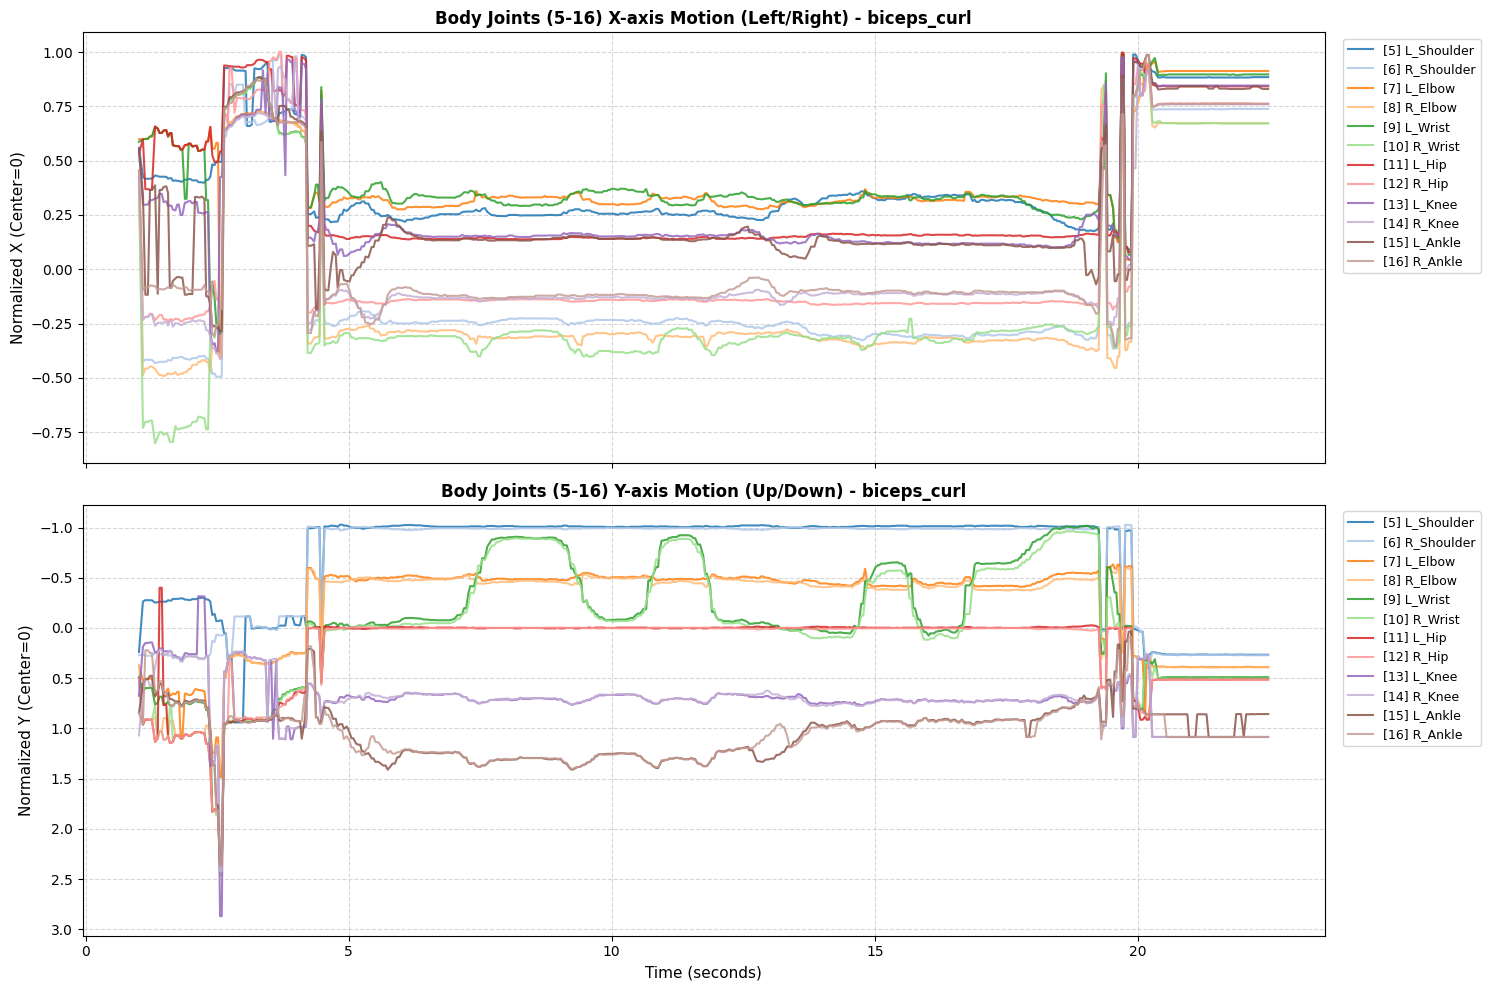

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------------------
# 1. 0~4번(얼굴) 제외 12개 신체 관절 정의
# ------------------------------------------------------------------------------
BODY_KPTS = {
    5: ("L_Shoulder", "#1f77b4"),
    6: ("R_Shoulder", "#aec7e8"),
    7: ("L_Elbow", "#ff7f0e"),
    8: ("R_Elbow", "#ffbb78"),
    9: ("L_Wrist", "#2ca02c"),
    10: ("R_Wrist", "#98df8a"),
    11: ("L_Hip", "#d62728"),
    12: ("R_Hip", "#ff9896"),
    13: ("L_Knee", "#9467bd"),
    14: ("R_Knee", "#c5b0d5"),
    15: ("L_Ankle", "#8c564b"),
    16: ("R_Ankle", "#c49c94"),
}

# ------------------------------------------------------------------------------
# 2. X 좌표 / Y 좌표 시계열 분리 시각화 (상하 2단 구성)
# ------------------------------------------------------------------------------
fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# [상단] X 좌표 변화 (좌우 이동)
for kpt_idx, (name, color) in BODY_KPTS.items():
  x_series = keypoints[:, kpt_idx, 0]
  ax_x.plot(
      timestamps,
      x_series,
      label=f"[{kpt_idx}] {name}",
      color=color,
      linewidth=1.5,
      alpha=0.85,
  )

ax_x.set_title(
    f"Body Joints (5-16) X-axis Motion (Left/Right) - {exercise_name}",
    fontsize=12,
    fontweight="bold",
)
ax_x.set_ylabel("Normalized X (Center=0)", fontsize=11)
ax_x.grid(True, linestyle="--", alpha=0.5)
ax_x.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

# [하단] Y 좌표 변화 (상하 이동)
for kpt_idx, (name, color) in BODY_KPTS.items():
  y_series = keypoints[:, kpt_idx, 1]
  ax_y.plot(
      timestamps,
      y_series,
      label=f"[{kpt_idx}] {name}",
      color=color,
      linewidth=1.5,
      alpha=0.85,
  )

ax_y.set_title(
    f"Body Joints (5-16) Y-axis Motion (Up/Down) - {exercise_name}",
    fontsize=12,
    fontweight="bold",
)
ax_y.set_xlabel("Time (seconds)", fontsize=11)
ax_y.set_ylabel("Normalized Y (Center=0)", fontsize=11)
ax_y.grid(True, linestyle="--", alpha=0.5)
ax_y.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

# Y축은 신체 직관성을 위해 위로 올라갈 때 그래프 값도 올라가도록 반전
ax_y.invert_yaxis()

plt.tight_layout()
plt.show()

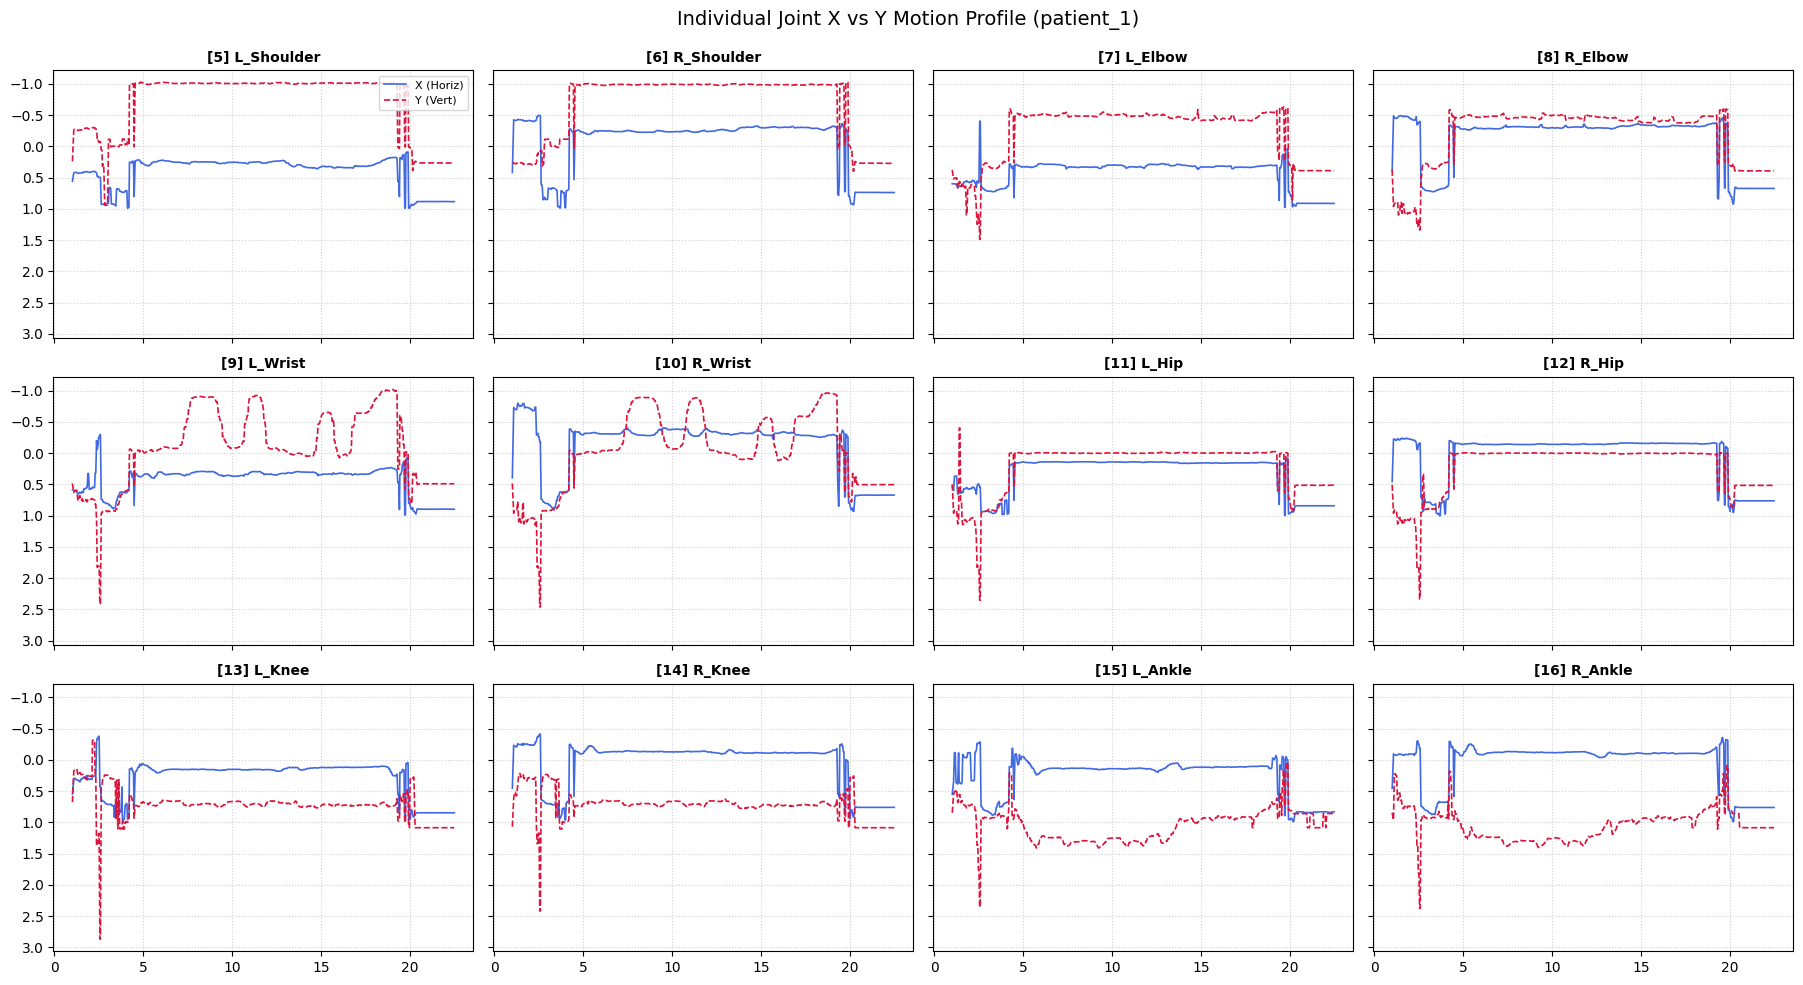

In [3]:
# ------------------------------------------------------------------------------
# 3. [선택] 12개 관절별 X/Y 개별 비교 서브플롯 (3행 4열 그리드)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (kpt_idx, (name, color)) in enumerate(BODY_KPTS.items()):
  ax = axes[i]
  x_series = keypoints[:, kpt_idx, 0]
  y_series = keypoints[:, kpt_idx, 1]

  ax.plot(
      timestamps,
      x_series,
      label="X (Horiz)",
      color="royalblue",
      linewidth=1.2,
  )
  ax.plot(
      timestamps,
      y_series,
      label="Y (Vert)",
      color="crimson",
      linewidth=1.2,
      linestyle="--",
  )

  ax.set_title(f"[{kpt_idx}] {name}", fontsize=10, fontweight="bold")
  ax.grid(True, linestyle=":", alpha=0.6)
  if i == 0:
    ax.legend(loc="upper right", fontsize=8)

axes[0].invert_yaxis()
plt.suptitle(
    f"Individual Joint X vs Y Motion Profile ({player_id})",
    fontsize=14,
    y=0.98,
)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

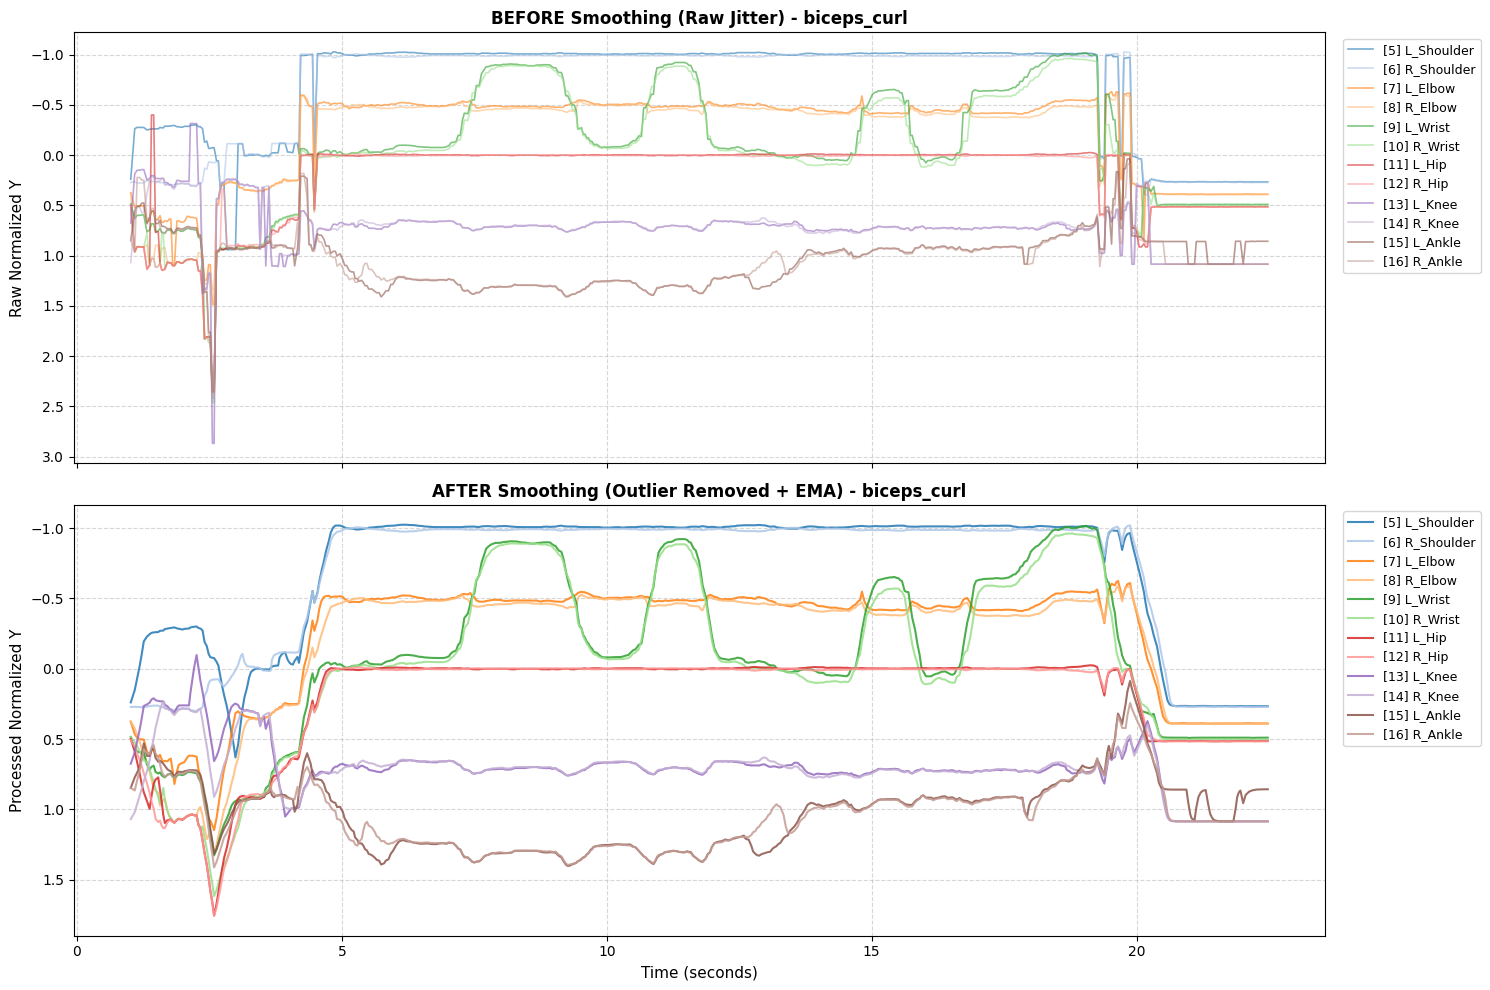

In [ ]:
# ==============================================================================
# [파일 정보]
# 파일명: compare_smoothing_effect.py
# 작성자: 개발자 (Developer)
# 설명: 12개 신체 관절(5~16번) 시계열 데이터에 후처리(이상치 제거 및 EMA 스무딩) 적용 전후 비교 시각화 스크립트
# 주요 기능:
#    1. remove_outliers_and_smooth 함수를 통한 관절 튐 현상(Outlier) 차단 및 EMA 스무딩 처리
#    2. 얼굴(0~4번)을 제외한 12개 주요 관절 매핑 정의
#    3. 후처리 적용 전(Raw)과 후(Processed)의 시계열 변화를 2단 서브플롯으로 나란히 비교 렌더링
#    4. Y축 반전 설정을 통한 인체 직관적 상하 움직임 반영 및 레이아웃 자동 정렬
# ==============================================================================

# ------------------------------------------------------------------------------
# [코드 설명]
# 본 스크립트는 후처리를 거치지 않은 원본 키포인트 데이터(Raw)와
# 이상치 제거 및 EMA 스무딩이 모두 적용된 데이터(Processed)를 동시에 비교할 수 있도록 구성되었습니다.
# 상단에는 원본 데이터의 거친 움직임을 보여주고, 하단에는 후처리를 통해 잔떨림이 제거된 깨끗한 궤적을
# 대조하여 시각화함으로써 후처리의 효과를 명확하게 확인할 수 있습니다.
# ------------------------------------------------------------------------------

import numpy as np  # 배열 연산 및 수학적 처리를 위한 NumPy 라이브러리 로드
import matplotlib.pyplot as plt  # 시계열 그래프 비교 렌더링을 위한 Matplotlib 라이브러리 로드


def remove_outliers_and_smooth(keypoints: np.ndarray, max_jump: float = 0.15, alpha: float = 0.6) -> np.ndarray:  # 이상치 제거 및 EMA 스무딩 수행 함수 정의
    num_frames, num_joints, num_dims = keypoints.shape  # 키포인트 배열의 프레임 수, 관절 수, 차원 수집
    smoothed_kpts = np.copy(keypoints)  # 원본 데이터 보호를 위한 복사본 배열 생성
    
    for j in range(num_joints):  # 17개 관절 인덱스별 순회
        prev_valid = None  # 직전 유효 좌표 추적 변수 초기화
        for f in range(num_frames):  # 전체 타임프레임 순회
            curr = smoothed_kpts[f, j, :2]  # 현재 프레임의 (X, Y) 좌표 추출
            
            if np.any(np.isnan(curr)) or np.all(curr == 0):  # 관절 좌표가 유실된 경우
                if prev_valid is not None:  # 이전 유효 좌표가 존재하면
                    smoothed_kpts[f, j, :2] = prev_valid  # 결측치를 직전 값으로 대체
                continue  # 다음 프레임으로 진행
                
            if prev_valid is not None:  # 직전 유효 좌표가 있는 경우 이상치 검사 수행
                distance = np.linalg.norm(curr - prev_valid)  # 직전 프레임과의 유클리드 이동 거리 계산
                if distance > max_jump:  # 이동 거리가 임계값을 초과하는 튐 현상인 경우
                    curr = prev_valid + (curr - prev_valid) * (max_jump / distance)  # 변화량 제한
                    
                # EMA(지수 이동 평균) 스무딩 적용: smoothed = alpha * curr + (1 - alpha) * prev
                curr = alpha * curr + (1.0 - alpha) * prev_valid  # 가중 평균을 통한 잔떨림 감쇄
                
            smoothed_kpts[f, j, :2] = curr  # 후처리가 완료된 좌표를 결과 배열에 대입
            prev_valid = curr  # 현재 좌표를 다음 반복을 위한 직전 유효 좌표로 갱신
            
    return smoothed_kpts  # 후처리 및 스무딩이 완료된 관절 배열 반환


# ------------------------------------------------------------------------------
# 1. 0~4번(얼굴) 제외 12개 신체 관절 정의 및 색상 매핑
# ------------------------------------------------------------------------------
BODY_KPTS = {  # 시각화 대상 12개 신체 관절 딕셔너리 선언
    5: ("L_Shoulder", "#1f77b4"),  # 5번 좌측 어깨 및 색상 지정
    6: ("R_Shoulder", "#aec7e8"),  # 6번 우측 어깨 및 색상 지정
    7: ("L_Elbow", "#ff7f0e"),  # 7번 좌측 팔꿈치 및 색상 지정
    8: ("R_Elbow", "#ffbb78"),  # 8번 우측 팔꿈치 및 색상 지정
    9: ("L_Wrist", "#2ca02c"),  # 9번 좌측 손목 및 색상 지정
    10: ("R_Wrist", "#98df8a"),  # 10번 우측 손목 및 색상 지정
    11: ("L_Hip", "#d62728"),  # 11번 좌측 골반 및 색상 지정
    12: ("R_Hip", "#ff9896"),  # 12번 우측 골반 및 색상 지정
    13: ("L_Knee", "#9467bd"),  # 13번 좌측 무릎 및 색상 지정
    14: ("R_Knee", "#c5b0d5"),  # 14번 우측 무릎 및 색상 지정
    15: ("L_Ankle", "#8c564b"),  # 15번 좌측 발목 및 색상 지정
    16: ("R_Ankle", "#c49c94"),  # 16번 우측 발목 및 색상 지정
}  # 관절 정의 매핑 완료

# ------------------------------------------------------------------------------
# 2. 후처리 적용 전후 데이터 준비
# ------------------------------------------------------------------------------
raw_keypoints = keypoints  # 후처리 적용 전 원본 키포인트 데이터 백업
processed_keypoints = remove_outliers_and_smooth(keypoints, max_jump=0.15, alpha=0.6)  # 이상치 제거 및 스무딩 적용된 데이터 생성

# ------------------------------------------------------------------------------
# 3. Y 좌표 기준 후처리 적용 전(Raw)과 후(Processed) 비교 시각화 (상하 2단 구성)
# ------------------------------------------------------------------------------
fig, (ax_raw, ax_proc) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)  # 상하 2개의 비교 서브플롯 생성

# [상단] 후처리 적용 전 (Raw 데이터 - 노이즈 및 튐 현상 포함)
for kpt_idx, (name, color) in BODY_KPTS.items():  # 12개 관절 순회
    y_raw = raw_keypoints[:, kpt_idx, 1]  # 원본 Y 좌표 시계열 추출
    ax_raw.plot(  # 원본 데이터 꺾은선 그래프 플롯
        timestamps,  # X축 타임스탬프
        y_raw,  # Y축 원본 좌표
        label=f"[{kpt_idx}] {name}",  # 범례 라벨
        color=color,  # 관절별 색상
        linewidth=1.2,  # 선 두께
        alpha=0.6,  # 투명도
    )  # 플롯 추가 완료

ax_raw.set_title(  # 상단 타이틀 설정
    f"BEFORE Smoothing (Raw Jitter) - {exercise_name}",  # 타이틀 조합
    fontsize=12,  # 폰트 크기
    fontweight="bold",  # 폰트 굵기
)  # 설정 완료
ax_raw.set_ylabel("Raw Normalized Y", fontsize=11)  # Y축 레이블
ax_raw.grid(True, linestyle="--", alpha=0.5)  # 그리드 활성화
ax_raw.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)  # 우측 범례 배치

# [하단] 후처리 적용 후 (Processed 데이터 - 이상치 제거 및 EMA 스무딩 완료)
for kpt_idx, (name, color) in BODY_KPTS.items():  # 12개 관절 순회
    y_proc = processed_keypoints[:, kpt_idx, 1]  # 후처리된 Y 좌표 시계열 추출
    ax_proc.plot(  # 후처리된 데이터 꺾은선 그래프 플롯
        timestamps,  # X축 타임스탬프
        y_proc,  # Y축 정제된 좌표
        label=f"[{kpt_idx}] {name}",  # 범례 라벨
        color=color,  # 관절별 색상
        linewidth=1.5,  # 선 두께
        alpha=0.85,  # 투명도
    )  # 플롯 추가 완료

ax_proc.set_title(  # 하단 타이틀 설정
    f"AFTER Smoothing (Outlier Removed + EMA) - {exercise_name}",  # 타이틀 조합
    fontsize=12,  # 폰트 크기
    fontweight="bold",  # 폰트 굵기
)  # 설정 완료
ax_proc.set_xlabel("Time (seconds)", fontsize=11)  # X축 레이블
ax_proc.set_ylabel("Processed Normalized Y", fontsize=11)  # Y축 레이블
ax_proc.grid(True, linestyle="--", alpha=0.5)  # 그리드 활성화
ax_proc.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)  # 우측 범례 배치

# 신체 직관성을 위해 두 그래프 모두 Y축 반전 적용 (위로 올라갈수록 값이 커짐)
ax_raw.invert_yaxis()  # 상단 Y축 반전
ax_proc.invert_yaxis()  # 하단 Y축 반전

plt.tight_layout()
plt.show()  # 비교 시각화 그래프 화면 출력

In [7]:
print("dk")

dk
